# Evoluzione e sviluppo della specie — dinosauri prima del K-Pg

**Domanda guida:** se l'asteroide non fosse caduto, i dinosauri (non-aviani) avevano possibilità di sopravvivere?
L'evoluzione li stava stabilizzando come specie dominante, oppure li stava già trasformando in qualcosa di troppo
diverso dal dinosauro "classico" — cioè nella linea che porta agli uccelli (Maniraptora / Paraves / Avialae basali,
qui chiamata "linea aviaria")?

Il notebook lavora solo sul dataset dinosauri (`data/processed/dinos_clean.csv`), già ripulito dal team
(vedi `notebooks/test/cleaning_Danilo.ipynb` e `etl/README.md`). Non modifica i CSV condivisi: tutte le feature
create qui (`stage_bin`, `linea_evolutiva`, `genus_noto`) sono locali al notebook, pensate per essere validate
qui e poi ricostruite in Power Query/DAX lato Power BI, senza toccare lo schema condiviso su Supabase.

## Struttura

1. Setup e caricamento dati
2. Perché serve una granularità temporale più fine
3. Feature: bin temporale fine (`stage_bin`)
4. Feature: linea evolutiva (classica vs aviaria)
5. Gestione dei generi non identificati
6. Ricchezza tassonomica nel tempo
7. Turnover: comparse e ultime occorrenze per bin
8. Quota della linea aviaria nel tempo
9. Conclusioni

## 1. Setup e caricamento dati

### 1.1 Import librerie

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
classico = 'firebrick'
aviario = 'steelblue'


### 1.2 Caricamento dataset dinosauri

In [2]:
DATA_PATH = Path('../../data/processed/dinos_clean.csv')
df = pd.read_csv(DATA_PATH, low_memory=False)
df.shape


(21663, 23)

### 1.3 Anteprima colonne rilevanti

In [3]:
df[['occurrence_no', 'accepted_name', 'genus', 'family', 'order', 'class',
    'early_interval', 'period_group', 'mid_ma']].head()


,occurrence_no,accepted_name,genus,family,order,class,early_interval,period_group,mid_ma
0,130209,Chaoyangsaurus youngi,Chaoyangsaurus,Chaoyangsauridae,NO_ORDER_SPECIFIED,Ornithischia,Late Kimmeridgian,Jurassic,142.405
1,130294,Protarchaeopteryx robusta,Protarchaeopteryx,NO_FAMILY_SPECIFIED,NO_ORDER_SPECIFIED,Reptilia,Late Barremian,Cretaceous,122.670
2,130295,Caudipteryx zoui,Caudipteryx,NO_FAMILY_SPECIFIED,NO_ORDER_SPECIFIED,Reptilia,Late Barremian,Cretaceous,122.670
3,137486,Theropoda,Unknown,Unknown,Unknown,Reptilia,Middle Campanian,Cretaceous,77.900
4,138867,Dinosauria,Unknown,Unknown,Unknown,Reptilia,Berriasian,Cretaceous,128.150


## 2. Perché serve una granularità temporale più fine

### 2.1 Occorrenze per periodo geologico

`period_group` ha solo 3 valori (Triassico, Giurassico, Cretaceo): utile come prima vista, ma troppo grezzo per guardare cosa succede *appena prima* del confine K-Pg (66 Ma), che cade all'interno del solo Cretaceo.

In [4]:
ordine_periodi = ['Triassic', 'Jurassic', 'Cretaceous']
conteggio_periodi = df['period_group'].value_counts().reindex(ordine_periodi)
conteggio_periodi


period_group
Triassic       2007
Jurassic       3902
Cretaceous    15754
Name: count, dtype: int64

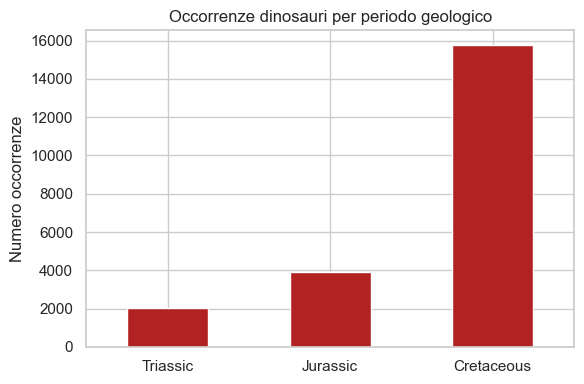

In [5]:
conteggio_periodi.plot(kind='bar', color=classico, figsize=(6, 4))
plt.title('Occorrenze dinosauri per periodo geologico')
plt.ylabel('Numero occorrenze')
plt.xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 2.2 Dentro il Cretaceo: gli stage di `early_interval`

Stessa cosa ma filtrata sul Cretaceo e ordinata per età media (`mid_ma`), cosi' vediamo la sequenza cronologica reale.

In [6]:
cret = df[df['period_group'] == 'Cretaceous'].copy()

eta_media_stage = cret.groupby('early_interval')['mid_ma'].mean().sort_values(ascending=False)
conteggio_stage = cret['early_interval'].value_counts().reindex(eta_media_stage.index)
conteggio_stage.head(25)


early_interval
Middle Berriasian     29
Berriasian           397
Late Berriasian      170
Early Berriasian      81
Early Valanginian     30
Late Valanginian      53
Neocomian             36
Valanginian          306
Early Hauterivian      2
Hauterivian           99
Late Hauterivian     169
Early Barremian      250
Late Barremian       458
Early Cretaceous     172
Early Aptian          79
Barremian            330
Late Aptian          230
Aptian               904
Early Albian         243
Gallic                 1
Albian               373
Cretaceous            29
Middle Albian        136
Late Albian          260
Early Cenomanian     465
Name: count, dtype: int64

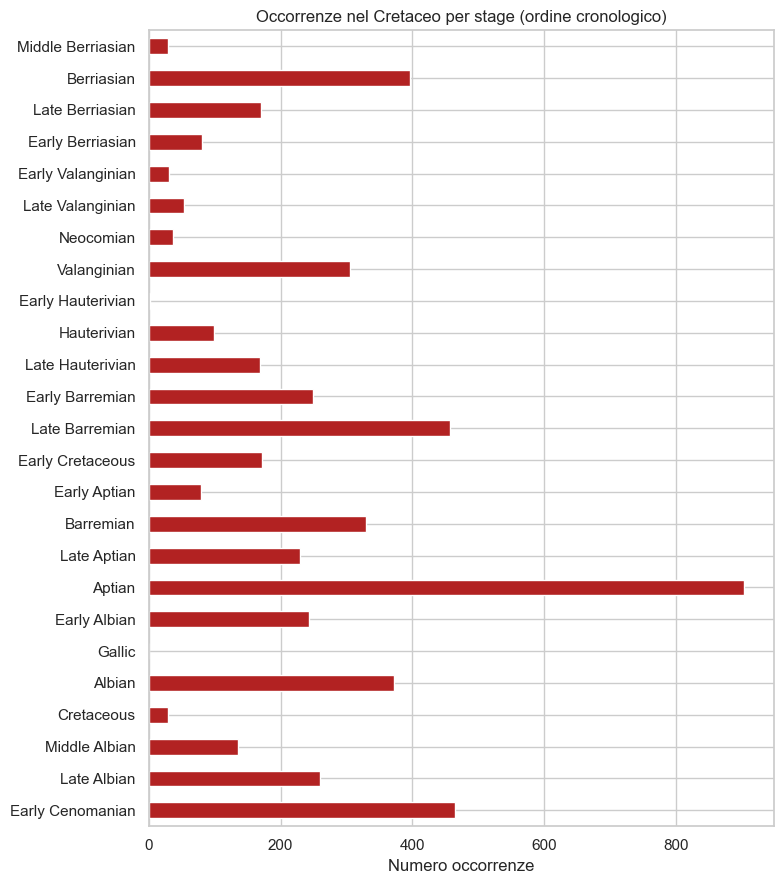

In [7]:
plt.figure(figsize=(8, 9))
conteggio_stage.head(25).iloc[::-1].plot(kind='barh', color=classico)
plt.title('Occorrenze nel Cretaceo per stage (ordine cronologico)')
plt.xlabel('Numero occorrenze')
plt.ylabel('')
plt.tight_layout()
plt.show()


### 2.3 Nota

Gli stage sono frammentati in varianti come `Campanian`, `Early Campanian`, `Middle Campanian`, `Late Campanian`:
stesso stage geologico, ma trattato come 4 categorie distinte in `early_interval`. Usare `early_interval` cosi'
com'e' per un confronto quantitativo nel tempo e' fuorviante. Conviene costruire bin numerici basati su `mid_ma`,
che e' continuo e confrontabile.

## 3. Feature: bin temporale fine (`stage_bin`)

### 3.1 Costruzione dei bin

Bin di ampiezza 5 milioni di anni su `mid_ma`, dalla fine del Cretaceo fino all'inizio del Triassico rappresentato nel dataset.

In [8]:
BIN_WIDTH = 5  # milioni di anni

bordo_massimo = int(np.ceil(df['mid_ma'].max() / BIN_WIDTH) * BIN_WIDTH)
bordi_bin = np.arange(0, bordo_massimo + BIN_WIDTH, BIN_WIDTH)

df['stage_bin'] = pd.cut(df['mid_ma'], bins=bordi_bin)
df['stage_bin_mid'] = df['stage_bin'].apply(lambda i: i.mid if pd.notnull(i) else np.nan).astype(float)

df[['mid_ma', 'stage_bin', 'stage_bin_mid']].head()


,mid_ma,stage_bin,stage_bin_mid
0,142.405,"(140, 145]",142.5
1,122.670,"(120, 125]",122.5
2,122.670,"(120, 125]",122.5
3,77.900,"(75, 80]",77.5
4,128.150,"(125, 130]",127.5


### 3.2 Distribuzione delle occorrenze nel tempo

Istogramma con il confine K-Pg (66 Ma) evidenziato. L'asse e' invertito: il tempo scorre da sinistra (passato remoto) verso destra (presente).

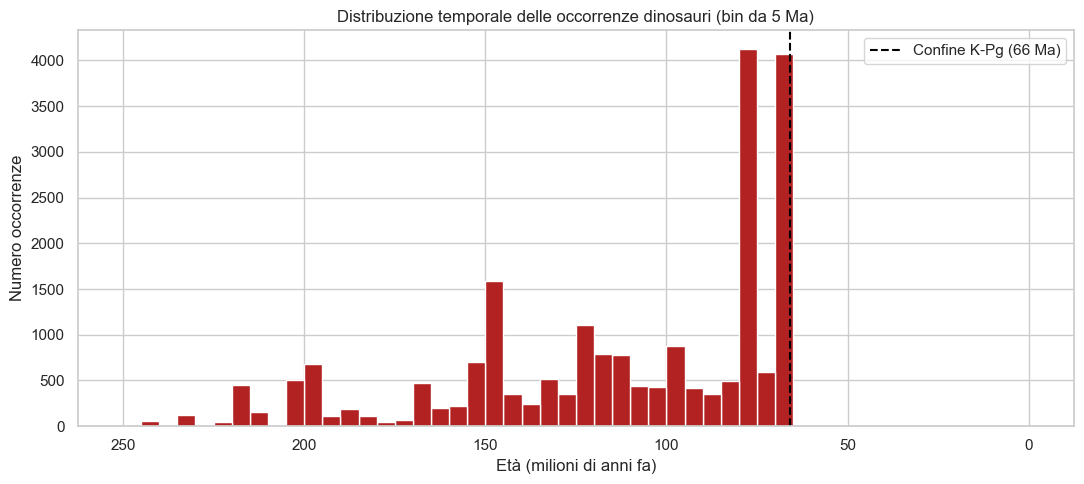

In [9]:
plt.figure(figsize=(11, 5))
plt.hist(df['mid_ma'].dropna(), bins=bordi_bin, color=classico, edgecolor='white')
plt.axvline(66, color='black', linestyle='--', label='Confine K-Pg (66 Ma)')
plt.gca().invert_xaxis()
plt.xlabel('Età (milioni di anni fa)')
plt.ylabel('Numero occorrenze')
plt.title('Distribuzione temporale delle occorrenze dinosauri (bin da 5 Ma)')
plt.legend()
plt.tight_layout()
plt.show()


### 3.3 Zoom sugli ultimi 20 milioni di anni prima del K-Pg

La finestra che conta davvero per rispondere alla domanda: cosa stava succedendo appena prima dell'impatto?

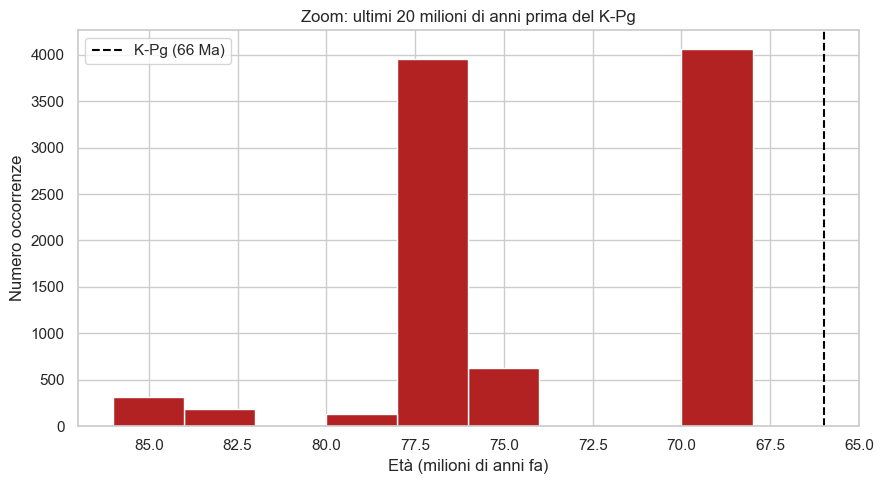

In [10]:
zoom = df[(df['mid_ma'] >= 66) & (df['mid_ma'] <= 86)]

plt.figure(figsize=(9, 5))
plt.hist(zoom['mid_ma'].dropna(), bins=np.arange(66, 88, 2), color=classico, edgecolor='white')
plt.axvline(66, color='black', linestyle='--', label='K-Pg (66 Ma)')
plt.gca().invert_xaxis()
plt.xlabel('Età (milioni di anni fa)')
plt.ylabel('Numero occorrenze')
plt.title('Zoom: ultimi 20 milioni di anni prima del K-Pg')
plt.legend()
plt.tight_layout()
plt.show()


### 3.4 Nota sui dati piu' recenti del K-Pg

Alcune occorrenze hanno `mid_ma` leggermente inferiore a 66: quasi certamente incertezza di datazione o fossili
rimaneggiati, non sopravvissuti reali alla dominanza non-aviana. Non vengono rimossi, ma vanno tenuti a mente
leggendo i grafici vicino al confine.

In [11]:
(df['mid_ma'] < 66).sum(), df.loc[df['mid_ma'] < 66, 'mid_ma'].min()


(np.int64(3), np.float64(62.620000000000005))

## 4. Feature: linea evolutiva (classica vs aviaria)

### 4.1 Definizione

`family`/`order` nel dataset contengono gia' gruppi riconoscibili in letteratura come Maniraptora/Paraves/Avialae
basali — cioe' la linea di teropodi piu' vicina agli uccelli moderni: `Dromaeosauridae`, `Troodontidae`,
`Oviraptoridae`, `Ornithomimidae`, `Ornithomimipodidae` (famiglie) e alcuni ordini di uccelli mesozoici arcaici
non filtrati dall'esclusione di `Aves` fatta a monte (`Hesperornithiformes`, `Ichthyornithes`,
`Alexornithiformes`, `Yanornithiformes`, `Cathayornithiformes`, `Eoenantiornithiformes`, `Jeholornithiformes`).

**Questa e' una classificazione editoriale**, costruita a mano da chi scrive in base alla letteratura
paleontologica, non un campo nativo del dataset PBDB. Va dichiarata esplicitamente ogni volta che si presentano
i risultati.

In [12]:
famiglie_aviarie = [
    'Dromaeosauridae', 'Troodontidae', 'Oviraptoridae',
    'Ornithomimidae', 'Ornithomimipodidae',
]
ordini_aviari = [
    'Hesperornithiformes', 'Ichthyornithes', 'Alexornithiformes',
    'Yanornithiformes', 'Cathayornithiformes', 'Eoenantiornithiformes',
    'Jeholornithiformes',
]

df['linea_evolutiva'] = np.where(
    df['family'].isin(famiglie_aviarie) | df['order'].isin(ordini_aviari),
    'Linea aviaria', 'Linea classica',
)
df['linea_evolutiva'].value_counts()


linea_evolutiva
Linea classica    19843
Linea aviaria      1820
Name: count, dtype: int64

### 4.2 Distribuzione per periodo geologico

In [13]:
tabella_periodo = pd.crosstab(df['period_group'], df['linea_evolutiva']).reindex(ordine_periodi)
tabella_periodo


linea_evolutiva,Linea aviaria,Linea classica
period_group,,
Triassic,0,2007
Jurassic,45,3857
Cretaceous,1775,13979


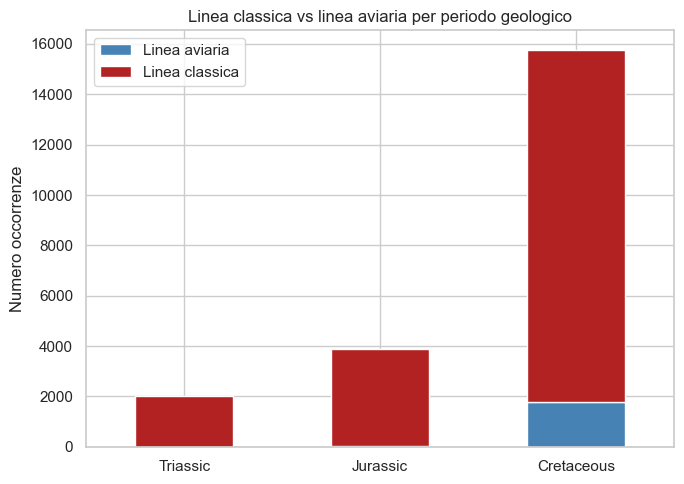

In [14]:
tabella_periodo[['Linea aviaria', 'Linea classica']].plot(
    kind='bar', stacked=True, color=[aviario, classico], figsize=(7, 5)
)
plt.title('Linea classica vs linea aviaria per periodo geologico')
plt.ylabel('Numero occorrenze')
plt.xlabel('')
plt.xticks(rotation=0)
plt.legend(title='')
plt.tight_layout()
plt.show()


## 5. Gestione dei generi non identificati

### 5.1 Flag `genus_noto`

Circa meta' delle occorrenze ha `genus` valorizzato a `Unknown`: va escluso dai conteggi di ricchezza tassonomica
(altrimenti "Unknown" verrebbe contato come un genere), ma senza eliminare le righe, che restano utili per i
conteggi di occorrenze.

In [15]:
df['genus_noto'] = df['genus'].notna() & ~df['genus'].isin(['Unknown', 'NO_GENUS_SPECIFIED'])

print('Quota genus noto, per riga:', round(df['genus_noto'].mean() * 100, 1), '%')
df.groupby('linea_evolutiva')['genus_noto'].mean().round(3)


Quota genus noto, per riga: 44.8 %


linea_evolutiva
Linea aviaria     0.633
Linea classica    0.431
Name: genus_noto, dtype: float64

## 6. Ricchezza tassonomica nel tempo

### 6.1 Generi distinti per bin temporale e linea evolutiva

In [16]:
noti = df[df['genus_noto']]

ricchezza = (
    noti.groupby(['stage_bin_mid', 'linea_evolutiva'])['genus']
    .nunique()
    .unstack('linea_evolutiva')
    .fillna(0)
    .sort_index(ascending=False)
)
ricchezza.tail(15)


linea_evolutiva,Linea aviaria,Linea classica
stage_bin_mid,,
132.5,6.0,55.0
127.5,1.0,51.0
122.5,20.0,145.0
117.5,17.0,159.0
112.5,7.0,98.0
107.5,8.0,47.0
102.5,7.0,43.0
97.5,14.0,125.0
92.5,16.0,43.0


### 6.2 Ricchezza tassonomica lungo tutto l'intervallo

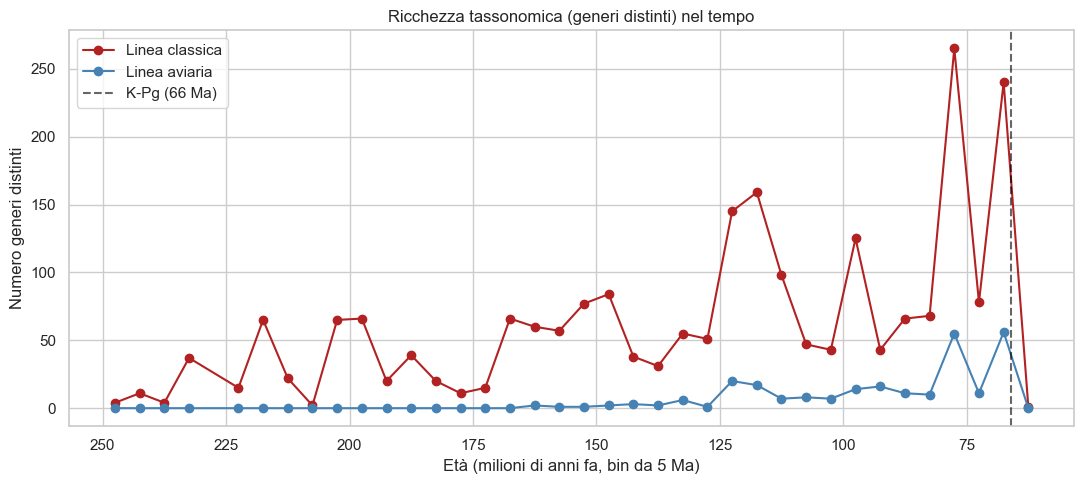

In [17]:
plt.figure(figsize=(11, 5))
plt.plot(ricchezza.index, ricchezza['Linea classica'], color=classico, marker='o', label='Linea classica')
plt.plot(ricchezza.index, ricchezza['Linea aviaria'], color=aviario, marker='o', label='Linea aviaria')
plt.axvline(66, color='black', linestyle='--', alpha=0.6, label='K-Pg (66 Ma)')
plt.gca().invert_xaxis()
plt.xlabel('Età (milioni di anni fa, bin da 5 Ma)')
plt.ylabel('Numero generi distinti')
plt.title('Ricchezza tassonomica (generi distinti) nel tempo')
plt.legend()
plt.tight_layout()
plt.show()


### 6.3 Zoom sugli ultimi bin prima del K-Pg

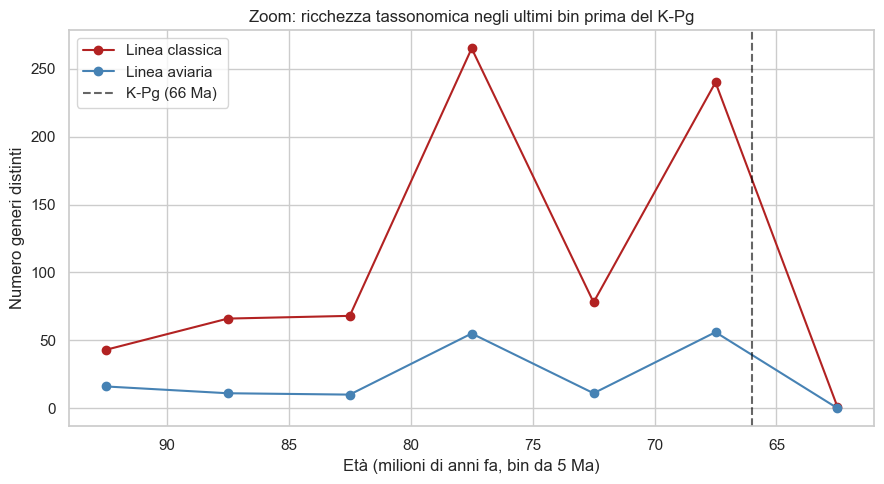

In [18]:
ricchezza_zoom = ricchezza[ricchezza.index <= 96]

plt.figure(figsize=(9, 5))
plt.plot(ricchezza_zoom.index, ricchezza_zoom['Linea classica'], color=classico, marker='o', label='Linea classica')
plt.plot(ricchezza_zoom.index, ricchezza_zoom['Linea aviaria'], color=aviario, marker='o', label='Linea aviaria')
plt.axvline(66, color='black', linestyle='--', alpha=0.6, label='K-Pg (66 Ma)')
plt.gca().invert_xaxis()
plt.xlabel('Età (milioni di anni fa, bin da 5 Ma)')
plt.ylabel('Numero generi distinti')
plt.title('Zoom: ricchezza tassonomica negli ultimi bin prima del K-Pg')
plt.legend()
plt.tight_layout()
plt.show()


## 7. Turnover: comparse e ultime occorrenze per bin

### 7.1 Prima e ultima comparsa per genere

Per ogni genere noto, calcolo il `mid_ma` piu' alto (comparsa piu' antica) e piu' basso (occorrenza piu' recente
nel dataset).

In [19]:
prima_ultima = noti.groupby('genus')['mid_ma'].agg(
    comparsa_ma='max', ultima_occorrenza_ma='min'
)
linea_per_genere = noti.groupby('genus')['linea_evolutiva'].first()
prima_ultima = prima_ultima.join(linea_per_genere)
prima_ultima.head()


,comparsa_ma,ultima_occorrenza_ma,linea_evolutiva
genus,,,
Aardonyx,197.15,197.15,Linea classica
Abavornis,91.85,91.85,Linea aviaria
Abdarainurus,78.95,78.95,Linea classica
Abditosaurus,69.10,69.10,Linea classica
Abelichnus,97.20,97.20,Linea classica


### 7.2 Attenzione: generi noti da un solo bin

Molti generi in PBDB sono noti da poche occorrenze concentrate in un solo bin: per questi, "comparsa" e
"ultima occorrenza" cadono nello stesso bin. In questi casi il conteggio non rappresenta una vera dinamica di
origination/estinzione biologica, ma solo l'estensione della finestra di ritrovamento nel record fossile.

In [20]:
prima_ultima['bin_comparsa'] = pd.cut(prima_ultima['comparsa_ma'], bins=bordi_bin).apply(
    lambda i: i.mid if pd.notnull(i) else np.nan
).astype(float)
prima_ultima['bin_ultima'] = pd.cut(prima_ultima['ultima_occorrenza_ma'], bins=bordi_bin).apply(
    lambda i: i.mid if pd.notnull(i) else np.nan
).astype(float)

quota_singolo_bin = (prima_ultima['bin_comparsa'] == prima_ultima['bin_ultima']).mean()
print(f'Generi noti da un solo bin temporale: {quota_singolo_bin:.1%}')


Generi noti da un solo bin temporale: 78.8%


### 7.3 Origination ed estinzione per bin

In [21]:
origination = prima_ultima.groupby(['bin_comparsa', 'linea_evolutiva']).size().unstack(fill_value=0)
estinzione = prima_ultima.groupby(['bin_ultima', 'linea_evolutiva']).size().unstack(fill_value=0)

origination = origination.sort_index(ascending=False)
estinzione = estinzione.sort_index(ascending=False)
origination.tail(10)


linea_evolutiva,Linea aviaria,Linea classica
bin_comparsa,,
107.5,2,21
102.5,3,22
97.5,6,93
92.5,12,35
87.5,10,46
82.5,5,49
77.5,42,220
72.5,3,34
67.5,34,149


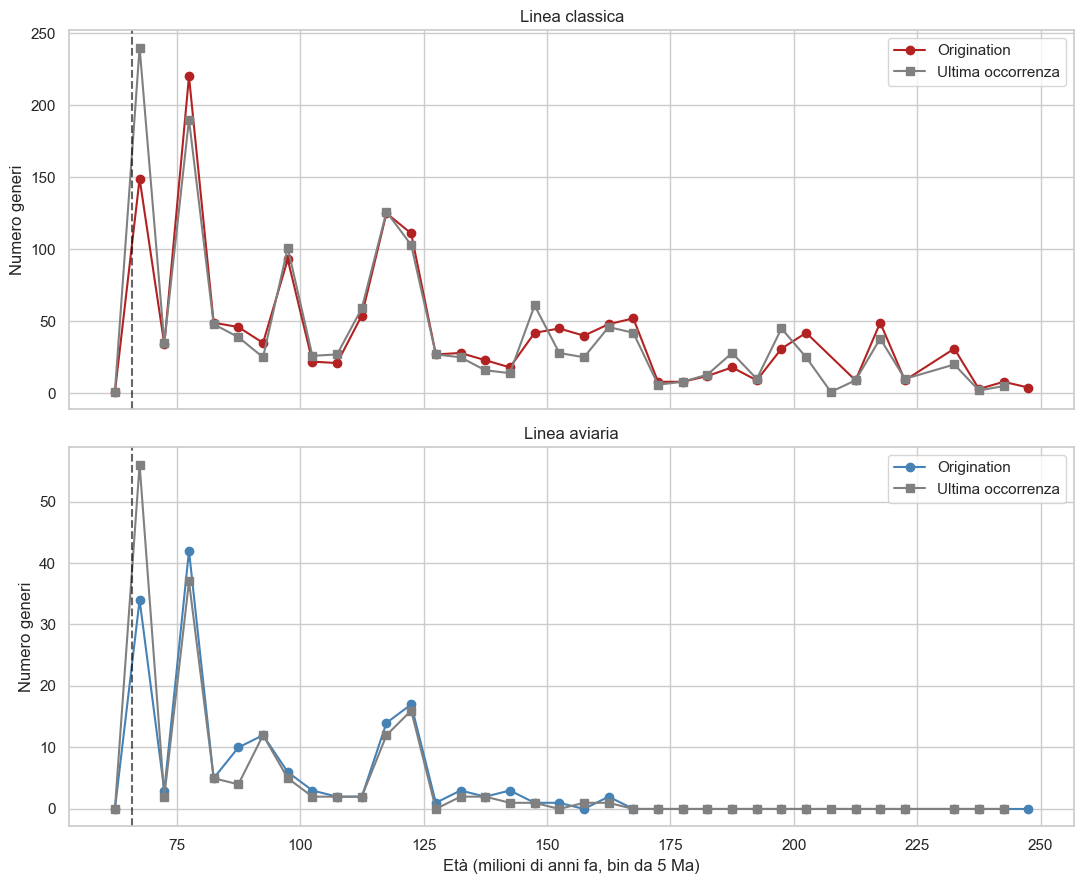

In [22]:
fig, assi = plt.subplots(2, 1, figsize=(11, 9), sharex=True)

assi[0].plot(origination.index, origination['Linea classica'], color=classico, marker='o', label='Origination')
assi[0].plot(estinzione.index, estinzione['Linea classica'], color='gray', marker='s', label='Ultima occorrenza')
assi[0].axvline(66, color='black', linestyle='--', alpha=0.6)
assi[0].set_title('Linea classica')
assi[0].legend()

assi[1].plot(origination.index, origination['Linea aviaria'], color=aviario, marker='o', label='Origination')
assi[1].plot(estinzione.index, estinzione['Linea aviaria'], color='gray', marker='s', label='Ultima occorrenza')
assi[1].axvline(66, color='black', linestyle='--', alpha=0.6)
assi[1].set_title('Linea aviaria')
assi[1].legend()

for ax in assi:
    ax.invert_xaxis()
    ax.set_ylabel('Numero generi')
assi[1].set_xlabel('Età (milioni di anni fa, bin da 5 Ma)')

plt.tight_layout()
plt.show()


## 8. Quota della linea aviaria nel tempo

### 8.1 Percentuale di generi noti in linea aviaria, per bin

In [23]:
quota_generi_aviaria = (
    ricchezza['Linea aviaria'] / (ricchezza['Linea aviaria'] + ricchezza['Linea classica'])
).replace([np.inf, -np.inf], np.nan) * 100

quota_generi_aviaria.tail(15)


stage_bin_mid
132.5     9.836066
127.5     1.923077
122.5    12.121212
117.5     9.659091
112.5     6.666667
107.5    14.545455
102.5    14.000000
97.5     10.071942
92.5     27.118644
87.5     14.285714
82.5     12.820513
77.5     17.187500
72.5     12.359551
67.5     18.918919
62.5      0.000000
dtype: float64

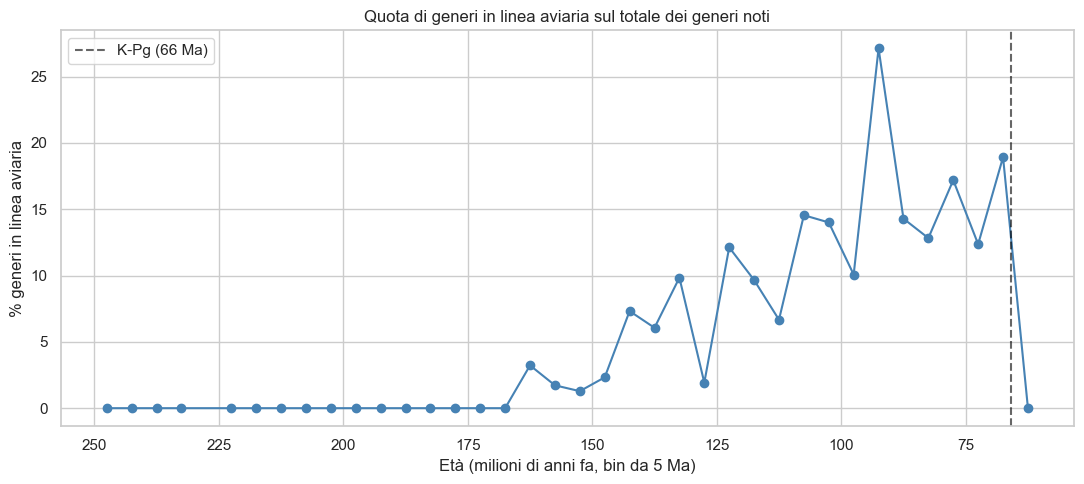

In [24]:
plt.figure(figsize=(11, 5))
plt.plot(quota_generi_aviaria.index, quota_generi_aviaria, color=aviario, marker='o')
plt.axvline(66, color='black', linestyle='--', alpha=0.6, label='K-Pg (66 Ma)')
plt.gca().invert_xaxis()
plt.xlabel('Età (milioni di anni fa, bin da 5 Ma)')
plt.ylabel('% generi in linea aviaria')
plt.title('Quota di generi in linea aviaria sul totale dei generi noti')
plt.legend()
plt.tight_layout()
plt.show()


### 8.2 Stesso indicatore, ultimi 20 milioni di anni prima del K-Pg

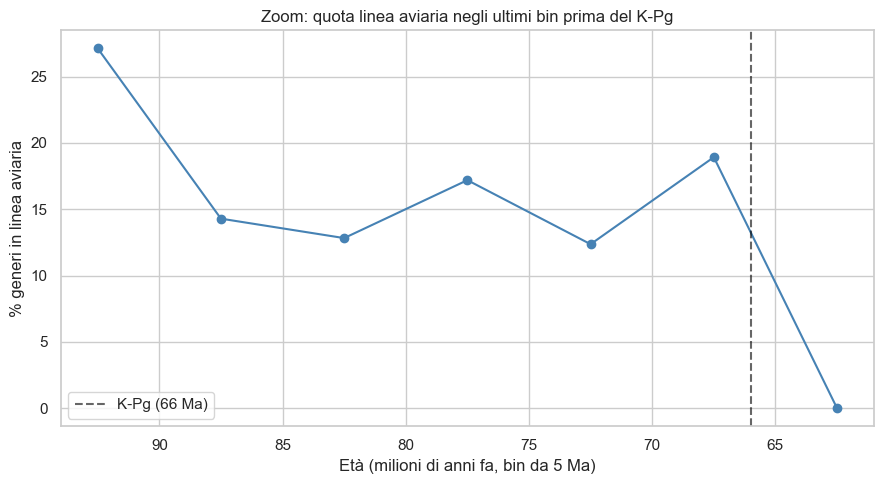

In [25]:
quota_zoom = quota_generi_aviaria[quota_generi_aviaria.index <= 96]

plt.figure(figsize=(9, 5))
plt.plot(quota_zoom.index, quota_zoom, color=aviario, marker='o')
plt.axvline(66, color='black', linestyle='--', alpha=0.6, label='K-Pg (66 Ma)')
plt.gca().invert_xaxis()
plt.xlabel('Età (milioni di anni fa, bin da 5 Ma)')
plt.ylabel('% generi in linea aviaria')
plt.title('Zoom: quota linea aviaria negli ultimi bin prima del K-Pg')
plt.legend()
plt.tight_layout()
plt.show()


## 9. Conclusioni

### Cosa mostrano i dati

- **Nessun crollo evidente della ricchezza tassonomica classica appena prima del K-Pg.** Nell'ultimo bin pieno prima del confine (67.5 Ma, grosso modo Maastrichtiano) si contano 240 generi noti di "linea classica", un livello vicino al massimo storico dell'intera serie (265 nel bin 77.5 Ma, circa Campaniano). A questa risoluzione (bin da 5 Ma) non si vede una specie che si sta lentamente spegnendo da sola.
- **Ma quel numero è probabilmente gonfiato dalla qualità del campionamento, non solo dalla biologia.** Il tardo Maastrichtiano (formazioni come Hell Creek e simili) è tra gli intervalli più studiati in assoluto nella paleontologia dei dinosauri: più ricerca vuol dire più generi trovati, a prescindere da quanto l'ecosistema fosse davvero ricco in quel momento. Il picco vicino al K-Pg va quindi letto come "non vediamo un declino", non come "c'era sicuramente stabilità biologica".
- **La quota di generi in "linea aviaria" (Maniraptora/Paraves/Avialae basali) sale nel tempo.** Nei bin del Giurassico/Cretaceo inferiore la linea aviaria pesa circa il 2-12% dei generi noti; negli ultimi ~25 milioni di anni prima del K-Pg oscilla tra il 12% e il 27%, restando comunque una quota rilevante e mai in calo fino alla fine. In altre parole: la parte di "dinosauria" più simile agli uccelli non si stava fermando, si stava ritagliando una fetta via via più grande della diversità totale.
- **Le famiglie/ordini della linea aviaria sono identificati al genere molto più spesso della linea classica** (63% contro 43% delle occorrenze), probabilmente perché i siti che li preservano (es. biota cinesi tipo Jehol) tendono a conservare scheletri più completi — un altro effetto di campionamento da tenere a mente, non un segnale biologico.
- **Il turnover (comparsa/ultima occorrenza per bin) va preso con grande cautela**: il 78,8% dei generi noti è documentato in un solo bin da 5 Ma. Per la maggior parte dei generi "origination" ed "estinzione" coincidono semplicemente perché li conosciamo da una manciata di fossili concentrati in una finestra stretta — non è evidenza diretta di vera speciazione o estinzione, ma della finestra con cui il record fossile li ha fatti arrivare fino a noi.

### Risposta (cauta) alla domanda guida

I dati a disposizione non mostrano un ecosistema di dinosauri classici già in declino nell'ultimo tratto del Cretaceo: la ricchezza tassonomica resta alta fino alla fine, quindi l'idea di una specie "già condannata" indipendentemente dall'asteroide non trova conferma diretta qui (anche tenendo conto del bias di campionamento a favore del tardo Maastrichtiano).

Allo stesso tempo, la linea aviaria non è marginale: rappresenta una quota stabilmente a due cifre della diversità nota negli ultimi milioni di anni, senza segni di rallentamento. Questo supporta l'idea che la "trasformazione verso gli uccelli" fosse un processo evolutivo attivo e in corso in parallelo alla presunta stabilità del resto del gruppo — non un'alternativa al declino, ma una terza traiettoria che stava comunque cambiando la composizione interna di "Dinosauria" indipendentemente da cosa sarebbe successo senza l'impatto.

In sintesi: più che "specie dominante e stabile" oppure "specie già in declino", il quadro più coerente con questi dati è **diversità classica ancora alta ma con una componente aviaria in crescita relativa** — l'evoluzione non stava necessariamente preparando l'estinzione dei dinosauri classici, ma stava già ridefinendo cosa significasse essere un dinosauro.

### Limiti

- Il dataset PBDB riflette l'intensità della ricerca paleontologica, non la biodiversità reale: formazioni molto studiate (es. tardo Maastrichtiano nordamericano) pesano più di altre.
- Solo il 44,8% delle occorrenze ha un genere identificato: i conteggi di ricchezza sono un limite inferiore, non il totale reale, e la copertura varia per bin e per linea evolutiva.
- La classificazione "linea aviaria" è una scelta editoriale basata su famiglie/ordini noti in letteratura (Dromaeosauridae, Troodontidae, Oviraptoridae, Ornithomimidae, Ornithomimipodidae, più alcuni ordini di uccelli mesozoici arcaici) applicata solo dove famiglia/ordine sono specificati: generi "Unknown" a livello di famiglia/ordine che in realtà appartengono alla linea aviaria non vengono conteggiati come tali, quindi la quota aviaria stimata è verosimilmente un limite inferiore.
- Bin da 5 Ma e datazioni (`mid_ma`) hanno un margine di incertezza stratigrafica non quantificato qui; alcuni bin (es. 92.5 Ma) hanno campioni piccoli (~59 generi totali) e le percentuali corrispondenti vanno lette con cautela.
- Come per il resto del progetto, queste sono analisi esplorative e descrittive: non permettono conclusioni causali forti su "cosa sarebbe successo senza l'asteroide".
